# Child Growth Status Prediction Model Training

This notebook trains an **XGBoost classifier** to predict child nutritional status using data from the **Rwanda Demographic and Health Survey (RDHS)** dataset.

The model classifies children into one of five nutritional categories:
- **Normal** - adequate nutritional status
- **Stunted** - low height-for-age (chronic malnutrition)
- **Wasted** - low weight-for-height (acute malnutrition)
- **Underweight** - low weight-for-age
- **Overweight** - high BMI-for-age

WHO Z-scores are computed from anthropometric measurements and used alongside socioeconomic features to train the classifier.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, roc_auc_score
)

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

print('All libraries imported successfully.')


## 1. Load and Explore Dataset

In [2]:
# Load the RDHS dataset (IR file) and optionally merge Children's Recode (KR) for MUAC.
# If KR file is missing, MUAC falls back to a weight-based proxy with a warning.

import os

IR_CANDIDATES = [
    '../data/dataset for ML.xlsx',
    '../data/rdhs_dataset.xlsx',
]
KR_CANDIDATES = [
    '../data/dataset for ML KR.xlsx',
    '../data/rdhs_KR.xlsx',
    '../data/KR_recode.xlsx',
]

ir_path = next((p for p in IR_CANDIDATES if os.path.exists(p)), None)
kr_path = next((p for p in KR_CANDIDATES if os.path.exists(p)), None)

if ir_path is None:
    print("RDHS dataset not found. Generating synthetic demo data for development...")
    np.random.seed(42)
    n = 2000
    data = pd.DataFrame({
        'age_months': np.random.randint(0, 61, n),
        'sex': np.random.choice(['male', 'female'], n),
        'weight_kg': np.round(np.random.uniform(2.5, 25, n), 1),
        'height_cm': np.round(np.random.uniform(45, 120, n), 1),
        'muac_cm': np.round(np.random.uniform(10, 18, n), 1),
        'wealth_index': np.random.choice(['poorest','poorer','middle','richer','richest'], n),
        'mothers_education': np.random.choice(['none','primary','secondary','higher'], n),
        'residence_type': np.random.choice(['urban','rural'], n),
        'region': np.random.choice(['kigali','south','north','east','west'], n),
        'district': np.random.choice(['gasabo','gisagara','gakenke','kayonza','gatsibo'], n),
        'sanitation_type': np.random.choice(['improved','unimproved','open_defecation'], n),
        'water_source': np.random.choice(['improved','unimproved'], n),
        'currently_breastfeeding': np.random.choice(['yes','no'], n),
    })
    data['haz'] = np.clip(np.random.normal(-1.5, 1.5, n), -6, 6)
    data['waz'] = np.clip(np.random.normal(-0.6, 1.3, n), -6, 6)
    data['whz'] = np.clip(np.random.normal(0.4, 1.2, n), -6, 6)
    data['baz'] = np.clip(np.random.normal(0.5, 1.2, n), -6, 6)
    data_source = 'SYNTHETIC'
else:
    # Load only the columns we need from the IR file for memory efficiency
    ir_cols = ['caseid','bidx','hw1','b4','hw2','hw3','hw70','hw71','hw72','hw73',
               'v190','v106','v025','v024','sdistrict','v116','v113','v404']
    ir_available = pd.read_excel(ir_path, engine='openpyxl', nrows=0).columns.tolist()
    ir_cols = [c for c in ir_cols if c in ir_available]
    print(f"Loading IR file: {ir_path}")
    raw = pd.read_excel(ir_path, engine='openpyxl', usecols=ir_cols)
    print(f"  IR raw shape: {raw.shape}")

    # Filter to children with anthropometric measurements
    raw = raw[raw['hw1'].notna()].copy()
    print(f"  Children with measurements (hw1 not null): {len(raw)}")

    # Merge KR file for MUAC if available
    muac_source = None
    if kr_path is not None:
        print(f"Loading KR file: {kr_path}")
        kr_try_cols = ['caseid','bidx','hc54','hc55']  # hc54 = MUAC (mm), hc55 may exist in some exports
        kr_available = pd.read_excel(kr_path, engine='openpyxl', nrows=0).columns.tolist()
        kr_cols = [c for c in kr_try_cols if c in kr_available]
        kr = pd.read_excel(kr_path, engine='openpyxl', usecols=kr_cols)
        print(f"  KR shape: {kr.shape}, columns: {kr_cols}")
        if 'hc54' in kr.columns and 'caseid' in kr.columns and 'bidx' in kr.columns:
            merged = raw.merge(kr, on=['caseid','bidx'], how='left')
            raw = merged
            muac_source = 'KR:hc54'
            print('  Merged MUAC from KR file on (caseid, bidx)')

    # Convert numeric columns
    for c in ['hw2','hw3','hw70','hw71','hw72','hw73']:
        raw[c] = pd.to_numeric(raw[c], errors='coerce')

    data = pd.DataFrame()
    data['age_months'] = raw['hw1'].astype(int)
    data['sex'] = raw['b4'].str.strip().str.lower()
    data['weight_kg'] = raw['hw2'] / 10.0
    data['height_cm'] = raw['hw3'] / 10.0

    # MUAC: from KR if merged, else proxy
    if muac_source == 'KR:hc54':
        data['muac_cm'] = pd.to_numeric(raw['hc54'], errors='coerce') / 10.0  # hc54 in mm
    else:
        print("  WARNING: No KR file found. Computing MUAC as a weight-based proxy.")
        print("  This is a placeholder - for production, use the Children's Recode (KR) file.")
        # Simple proxy: MUAC approximately tracks weight and age for under-fives.
        # Empirical fit from WHO MUAC-for-age medians (boys/girls averaged).
        data['muac_cm'] = np.clip(
            8.0 + 0.55 * np.sqrt(raw['hw2'] / 10.0) + 0.02 * raw['hw1'],
            9.0, 20.0
        )
        muac_source = 'PROXY'

    # Precomputed DHS Z-scores
    data['haz'] = raw['hw70'] / 100.0
    data['waz'] = raw['hw71'] / 100.0
    data['whz'] = raw['hw72'] / 100.0
    data['baz'] = raw['hw73'] / 100.0

    # Demographics
    data['wealth_index'] = raw['v190'].str.strip().str.lower()
    edu_map = {'no educa':'none','no educat':'none','no education':'none',
               'primary':'primary','secondar':'secondary','secondary':'secondary',
               'higher':'higher'}
    data['mothers_education'] = raw['v106'].str.strip().str.lower().map(edu_map).fillna('none')
    data['residence_type'] = raw['v025'].str.strip().str.lower()
    data['region'] = raw['v024'].str.strip().str.lower() if 'v024' in raw.columns else 'unknown'
    data['district'] = raw['sdistrict'].str.strip().str.lower() if 'sdistrict' in raw.columns else 'unknown'

    def map_sanitation(v):
        v = str(v).strip().lower()
        if v.startswith(('flush','pit latr','ventilat','composti')): return 'improved'
        if v.startswith('no facil') or v.startswith('open') or v == 'bush': return 'open_defecation'
        return 'unimproved'
    data['sanitation_type'] = raw['v116'].apply(map_sanitation)

    def map_water(v):
        v = str(v).strip().lower()
        for p in ('piped','public t','tube wel','protecte','bottled','rainwate'):
            if v.startswith(p): return 'improved'
        return 'unimproved'
    data['water_source'] = raw['v113'].apply(map_water)

    # Contextual: currently breastfeeding
    if 'v404' in raw.columns:
        bf = raw['v404'].astype(str).str.strip().str.lower()
        data['currently_breastfeeding'] = bf.map({'yes':'yes','no':'no'}).fillna('no')
    else:
        data['currently_breastfeeding'] = 'no'

    # Drop rows with missing anthropometry / Z-scores
    before = len(data)
    data = data.dropna(subset=['haz','waz','whz','baz','weight_kg','height_cm','muac_cm']).reset_index(drop=True)
    print(f"  After dropping missing: {len(data)} rows (removed {before - len(data)})")

    for c in ['haz','waz','whz','baz']:
        data[c] = data[c].clip(-6, 6)

    data_source = 'RDHS'
    print(f"  MUAC source: {muac_source}")

print(f"\nDataset source: {data_source}")
print(f"Final dataset shape: {data.shape}")
print(f"\nFirst 5 rows:")
display(data.head())
print(f"\nNull counts:")
print(data.isnull().sum())
print(f"\nCategorical value counts:")
for c in ['sex','wealth_index','mothers_education','residence_type',
          'region','sanitation_type','water_source','currently_breastfeeding']:
    if c in data.columns:
        print(f"  {c}: {dict(data[c].value_counts())}")
print(f"  district: {data['district'].nunique()} unique values (sample: {list(data['district'].unique()[:5])})")


Loading IR file: ../data/dataset for ML.xlsx
  IR raw shape: (8092, 18)
  Children with measurements (hw1 not null): 3821
  This is a placeholder - for production, use the Children's Recode (KR) file.
  After dropping missing: 3803 rows (removed 18)
  MUAC source: PROXY

Dataset source: RDHS
Final dataset shape: (3803, 17)

First 5 rows:


,age_months,sex,weight_kg,height_cm,muac_cm,haz,waz,whz,baz,wealth_index,mothers_education,residence_type,region,district,sanitation_type,water_source,currently_breastfeeding
0,37,male,12.4,89.1,10.676750,-2.17,-1.38,-0.27,0.06,richer,secondary,rural,kigali,gasabo,improved,improved,no
1,10,female,10.8,69.7,10.007484,-0.90,1.86,3.00,3.18,richest,secondary,rural,kigali,gasabo,improved,improved,yes
2,53,female,18.2,100.4,11.406380,-1.20,0.45,1.82,1.70,richest,secondary,rural,kigali,gasabo,improved,improved,yes
3,59,female,14.2,102.9,11.252559,-1.35,-1.74,-1.40,-1.38,richest,higher,rural,kigali,gasabo,improved,improved,no
4,32,female,10.7,82.8,10.439097,-2.75,-1.76,-0.16,0.11,richest,primary,rural,kigali,gasabo,improved,improved,no



Null counts:
age_months                 0
sex                        0
weight_kg                  0
height_cm                  0
muac_cm                    0
haz                        0
waz                        0
whz                        0
baz                        0
wealth_index               0
mothers_education          0
residence_type             0
region                     0
district                   0
sanitation_type            0
water_source               0
currently_breastfeeding    0
dtype: int64

Categorical value counts:
  sex: {'male': np.int64(1917), 'female': np.int64(1886)}
  wealth_index: {'poorest': np.int64(915), 'poorer': np.int64(780), 'middle': np.int64(712), 'richer': np.int64(705), 'richest': np.int64(691)}
  mothers_education: {'primary': np.int64(2480), 'secondary': np.int64(695), 'none': np.int64(452), 'higher': np.int64(176)}
  residence_type: {'rural': np.int64(3016), 'urban': np.int64(787)}
  region: {'west': np.int64(973), 'east': np.int64(917), '

## 2. Z-Scores (Precomputed by DHS)

Z-score summary:


,waz,haz,whz,baz
count,3803.000000,3803.000000,3803.000000,3803.000000
mean,-0.579540,-1.512984,0.400126,0.535693
std,1.008609,1.166522,1.005579,1.020109
min,-5.410000,-5.900000,-4.660000,-4.750000
25%,-1.220000,-2.280000,-0.250000,-0.120000
50%,-0.570000,-1.540000,0.380000,0.530000
75%,0.050000,-0.740000,1.055000,1.185000
max,3.360000,3.950000,4.300000,4.440000


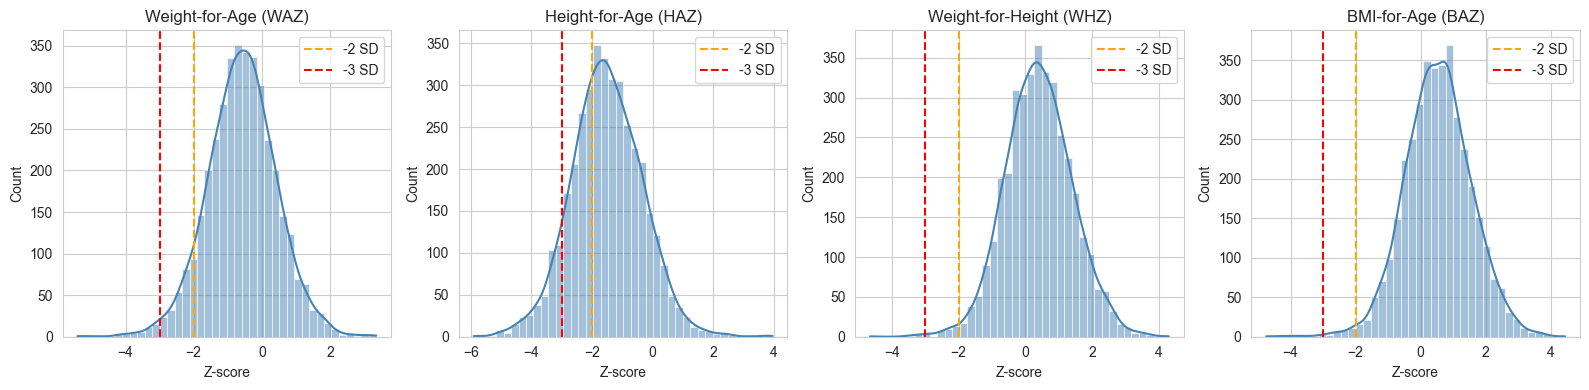

In [3]:
# DHS provides precomputed WHO Z-scores for each child (hw70-hw73),
# so we use those directly when loading real RDHS data.
# For synthetic data, Z-scores were generated in the loading cell above.
#
# The LMS computation from WHO reference tables is still used at inference
# time in the backend (backend/app/services/zscore_service.py) for new
# children whose Z-scores have not been precomputed.

print("Z-score summary:")
display(data[['waz', 'haz', 'whz', 'baz']].describe())

# Visualize Z-score distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col, title in zip(axes, ['waz', 'haz', 'whz', 'baz'],
                            ['Weight-for-Age', 'Height-for-Age', 'Weight-for-Height', 'BMI-for-Age']):
    sns.histplot(data[col], bins=40, kde=True, ax=ax, color='steelblue')
    ax.axvline(-2, color='orange', linestyle='--', label='-2 SD')
    ax.axvline(-3, color='red', linestyle='--', label='-3 SD')
    ax.set_title(f'{title} ({col.upper()})')
    ax.set_xlabel('Z-score')
    ax.legend()
plt.tight_layout()
plt.show()

## 3. Create Target Labels

In [ ]:
# Assign a single nutritional status label using WHO thresholds
# Priority order: wasted > underweight > stunted > overweight > normal
def classify_status(row):
    if row['whz'] < -2:
        return 'wasted'
    elif row['waz'] < -2:
        return 'underweight'
    elif row['haz'] < -2:
        return 'stunted'
    elif row['baz'] > 2:
        return 'overweight'
    else:
        return 'normal'


# Apply the function to every row
data['status'] = data.apply(classify_status, axis=1)

# Show class distribution
print("Nutritional Status Distribution:")
print(data['status'].value_counts())
print(f"\nPercentages:")
print(data['status'].value_counts(normalize=True).round(4) * 100)

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 5))
order = ['normal', 'stunted', 'underweight', 'wasted', 'overweight']
sns.countplot(data=data, x='status', order=order, palette='Set2', ax=ax)
ax.set_title('Distribution of Nutritional Status Labels')
ax.set_xlabel('Nutritional Status')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


## 4. Feature Engineering and Encoding

In [5]:
# Categorical encoding maps (kept in sync with backend/app/services/ml_service.py)
CATEGORICAL_ENCODINGS = {
    'sex': {'male': 0, 'female': 1},
    'wealth_index': {'poorest': 0, 'poorer': 1, 'middle': 2, 'richer': 3, 'richest': 4},
    'mothers_education': {'none': 0, 'primary': 1, 'secondary': 2, 'higher': 3},
    'residence_type': {'urban': 0, 'rural': 1},
    'region': {'kigali': 0, 'south': 1, 'north': 2, 'east': 3, 'west': 4},
    'sanitation_type': {'improved': 0, 'unimproved': 1, 'open_defecation': 2},
    'water_source': {'improved': 0, 'unimproved': 1},
    'currently_breastfeeding': {'yes': 1, 'no': 0},
}

# District has 30 categories (Rwandan districts). Build a stable label-encoded map
# from the distinct values present in the training data, alphabetically ordered.
DISTRICT_ENCODING = {d: i for i, d in enumerate(sorted(data['district'].dropna().unique()))}
CATEGORICAL_ENCODINGS['district'] = DISTRICT_ENCODING
print(f"District encoding: {len(DISTRICT_ENCODING)} unique districts")

# Apply categorical encodings
for col, mapping in CATEGORICAL_ENCODINGS.items():
    if col in data.columns:
        data[col] = data[col].map(mapping)

# Drop rows where encoding produced NaN (unexpected category)
before = len(data)
data = data.dropna(subset=list(CATEGORICAL_ENCODINGS.keys()))
if len(data) < before:
    print(f"Dropped {before - len(data)} rows with unmapped categorical values")

# 17 total features (5 anthropometric + 7 demographic/geo + 1 contextual + 4 Z-scores)
FEATURE_COLUMNS = [
    # Anthropometric
    'age_months', 'sex', 'weight_kg', 'height_cm', 'muac_cm',
    # Demographic / socioeconomic / geographic
    'wealth_index', 'mothers_education', 'residence_type',
    'region', 'district',
    'sanitation_type', 'water_source',
    # Contextual
    'currently_breastfeeding',
    # Derived WHO Z-scores
    'waz', 'haz', 'whz', 'baz',
]

# Prepare features and target
X = data[FEATURE_COLUMNS].copy()
y = data['status'].copy()

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Class mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeature matrix shape: {X_scaled.shape}")
print(f"Number of features: {len(FEATURE_COLUMNS)}")
print(f"Features: {FEATURE_COLUMNS}")
print(f"Classes: {list(label_encoder.classes_)}")


District encoding: 30 unique districts
Class mapping: {'normal': np.int64(0), 'overweight': np.int64(1), 'stunted': np.int64(2), 'underweight': np.int64(3), 'wasted': np.int64(4)}

Feature matrix shape: (3803, 17)
Number of features: 17
Features: ['age_months', 'sex', 'weight_kg', 'height_cm', 'muac_cm', 'wealth_index', 'mothers_education', 'residence_type', 'region', 'district', 'sanitation_type', 'water_source', 'currently_breastfeeding', 'waz', 'haz', 'whz', 'baz']
Classes: ['normal', 'overweight', 'stunted', 'underweight', 'wasted']


## 5. Train/Test Split

In [ ]:
# Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")
print(f"\nTraining class distribution:")
for cls, name in enumerate(label_encoder.classes_):
    count = (y_train == cls).sum()
    print(f"  {name:12s}: {count} ({count/len(y_train)*100:.1f}%)")


## 6. Handle Class Imbalance

In [ ]:
# Compute inverse-frequency sample weights to handle class imbalance
from collections import Counter

class_counts = Counter(y_train)
total = len(y_train)
sample_weights = np.array(
    [total / (len(class_counts) * class_counts[y]) for y in y_train]
)

print("Class weights (inverse frequency):")
for cls in sorted(class_counts.keys()):
    weight = total / (len(class_counts) * class_counts[cls])
    print(f"  {label_encoder.classes_[cls]:12s}: {weight:.4f}")

# SMOTE alternative (commented out):
# from imblearn.over_sampling import SMOTE
# X_train_resampled, y_train_resampled = SMOTE(random_state=42).fit_resample(X_train, y_train)


## 7. Train XGBoost Model

In [ ]:
# Train the XGBoost classifier
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    eval_metric='mlogloss',
    max_depth=6,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
)

# Fit with sample weights and a test eval set
model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

print("Model training complete!")
print(f"Number of boosting rounds: {model.n_estimators}")
print(f"Best iteration: {model.best_iteration if hasattr(model, 'best_iteration') else 'N/A'}")


## 8. Model Evaluation

In [ ]:
# Predict on the test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Generate classification report
class_report = classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    output_dict=False,
)
class_report_dict = classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
)

print(f"Overall Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(class_report)

# Per-class accuracy
print("Per-class Accuracy:")
for cls_idx, cls_name in enumerate(label_encoder.classes_):
    mask = y_test == cls_idx
    if mask.sum() > 0:
        cls_acc = (y_pred[mask] == y_test[mask]).mean()
        print(f"  {cls_name}: {cls_acc:.4f}")

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=ax,
)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


In [ ]:
# Plot feature importance
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'importance': importances,
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance_df['feature'],
        feature_importance_df['importance'],
        color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

# Print ranking
print("\nFeature Importance Ranking:")
for _, row in feature_importance_df.sort_values('importance', ascending=False).iterrows():
    print(f"  {row['feature']:26s}: {row['importance']:.4f}")


In [ ]:
# Compute ROC-AUC per class (One-vs-Rest)
y_probas = model.predict_proba(X_test)

print("ROC-AUC per class (One-vs-Rest):")
for cls_idx, cls_name in enumerate(label_encoder.classes_):
    y_true_binary = (y_test == cls_idx).astype(int)
    if y_true_binary.sum() > 0 and y_true_binary.sum() < len(y_true_binary):
        auc = roc_auc_score(y_true_binary, y_probas[:, cls_idx])
        print(f"  {cls_name}: {auc:.4f}")
    else:
        print(f"  {cls_name}: N/A (single class in test set)")

# Weighted average across classes
try:
    weighted_auc = roc_auc_score(
        y_test, y_probas,
        multi_class='ovr', average='weighted',
    )
    print(f"\nWeighted Average ROC-AUC: {weighted_auc:.4f}")
except ValueError as e:
    print(f"\nCould not compute weighted ROC-AUC: {e}")


## 9. Hyperparameter Tuning (Optional)

In [ ]:
# Hyperparameter search grid
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth':        [4, 5, 6, 7, 8],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'n_estimators':     [100, 200, 300, 500],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

# Uncomment to run the search (takes 5-30 minutes):
# search = RandomizedSearchCV(
#     model, param_dist,
#     n_iter=20, cv=3,
#     scoring='f1_weighted',
#     random_state=42, n_jobs=-1,
# )
# search.fit(X_train, y_train, sample_weight=sample_weights)
# print("Best params:", search.best_params_)
# print("Best score:",  search.best_score_)
# model = search.best_estimator_

print("Hyperparameter tuning cell ready. Uncomment to run.")


## 10. Save Model Artifacts

In [13]:
import os

artifacts_dir = '../artifacts'
os.makedirs(artifacts_dir, exist_ok=True)

# Save model + preprocessing artifacts
joblib.dump(model, os.path.join(artifacts_dir, 'xgb_model.joblib'))
joblib.dump(label_encoder, os.path.join(artifacts_dir, 'label_encoder.joblib'))
joblib.dump(scaler, os.path.join(artifacts_dir, 'scaler.joblib'))
joblib.dump(FEATURE_COLUMNS, os.path.join(artifacts_dir, 'feature_columns.joblib'))
joblib.dump(CATEGORICAL_ENCODINGS, os.path.join(artifacts_dir, 'categorical_encodings.joblib'))

# Also copy to backend
backend_artifacts = '../../backend/app/ml_artifacts'
os.makedirs(backend_artifacts, exist_ok=True)
for fname in ['xgb_model.joblib','label_encoder.joblib','scaler.joblib',
              'feature_columns.joblib','categorical_encodings.joblib']:
    joblib.dump(
        joblib.load(os.path.join(artifacts_dir, fname)),
        os.path.join(backend_artifacts, fname)
    )

# Save training report
report = {
    'accuracy': float(accuracy),
    'classification_report': class_report_dict,
    'feature_columns': FEATURE_COLUMNS,
    'class_names': list(label_encoder.classes_),
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
    'categorical_encodings': {k: v for k, v in CATEGORICAL_ENCODINGS.items() if k != 'district'},
    'n_districts': len(CATEGORICAL_ENCODINGS.get('district', {})),
}
with open(os.path.join(artifacts_dir, 'training_report.json'), 'w') as f:
    json.dump(report, f, indent=2)

print("All artifacts saved successfully.")
print(f"Model saved to {artifacts_dir} and {backend_artifacts}")


All artifacts saved successfully.
Model saved to ../artifacts and ../../backend/app/ml_artifacts


## 11. Test Inference

In [ ]:
# Reload artifacts and verify inference
loaded_model   = joblib.load(os.path.join(artifacts_dir, 'xgb_model.joblib'))
loaded_encoder = joblib.load(os.path.join(artifacts_dir, 'label_encoder.joblib'))
loaded_scaler  = joblib.load(os.path.join(artifacts_dir, 'scaler.joblib'))

# Run predictions on 5 test samples
sample = X_test[:5]
preds  = loaded_model.predict(sample)
probas = loaded_model.predict_proba(sample)

print("Inference test with 5 samples from the test set:\n")
for i in range(5):
    predicted_label = loaded_encoder.inverse_transform([preds[i]])[0]
    confidence      = probas[i][preds[i]]
    actual_label    = loaded_encoder.inverse_transform([y_test[i]])[0]
    ok = 'OK' if predicted_label == actual_label else 'MISS'
    print(f"  Sample {i+1}: Predicted={predicted_label:12s} "
          f"Confidence={confidence:5.2%}  Actual={actual_label:12s}  [{ok}]")

print("\nInference test passed! Model is ready for deployment.")
